In [23]:
import pickle
import pandas as pd
import numpy as np
import shap
import matplotlib.pyplot as plt
from ta.momentum import RSIIndicator, ROCIndicator
from ta.trend import MACD
from ta.volatility import BollingerBands, AverageTrueRange

In [24]:
with open("model_cat.pkl", "rb") as file:
    model_cat = pickle.load(file)

print("CatBoost model loaded successfully!")

CatBoost model loaded successfully!


In [25]:
# Load the original dataset
data = pd.read_csv("merged_data.csv")

# Convert Date to datetime
data["Date"] = pd.to_datetime(data["Date"])

print("Dataset shape:", data.shape)
print("Date range:", data["Date"].min(), "to", data["Date"].max())

Dataset shape: (1381571, 7)
Date range: 2000-01-01 00:00:00 to 2025-02-26 00:00:00


## **Feature Engineering**

In [26]:
from ta.momentum import RSIIndicator, ROCIndicator
from ta.trend import MACD
from ta.volatility import BollingerBands, AverageTrueRange

# Sort data
data = data.sort_values(
    ["Scrip", "Date"]
).reset_index(drop=True)


def add_features(group):

    close = group["Close"]
    high = group["High"]
    low = group["Low"]
    volume = group["Volume"]

    # -----------------------------
    # Basic Features
    # -----------------------------

    group["Return"] = close.pct_change()

    group["Return_Lag1"] = group["Return"].shift(1)
    group["Return_Lag2"] = group["Return"].shift(2)
    group["Return_Lag5"] = group["Return"].shift(5)

    group["Volatility_5"] = (
        group["Return"].rolling(5).std()
    )

    group["Volatility_20"] = (
        group["Return"].rolling(20).std()
    )

    group["Price_Range"] = (
        (high - low) / close
    )

    group["Volume_Change"] = volume.pct_change()

    group["Volume_SMA_20"] = (
        volume.rolling(20).mean()
    )


    # -----------------------------
    # RSI
    # -----------------------------

    if len(group) >= 14:

        rsi = RSIIndicator(
            close=close,
            window=14
        )

        group["RSI"] = rsi.rsi()

    else:

        group["RSI"] = np.nan


    # -----------------------------
    # MACD
    # -----------------------------

    if len(group) >= 26:

        macd = MACD(
            close=close,
            window_slow=26,
            window_fast=12,
            window_sign=9
        )

        group["MACD"] = macd.macd()
        group["MACD_Signal"] = macd.macd_signal()
        group["MACD_Hist"] = macd.macd_diff()

    else:

        group["MACD"] = np.nan
        group["MACD_Signal"] = np.nan
        group["MACD_Hist"] = np.nan


    # -----------------------------
    # Bollinger Band
    # -----------------------------

    if len(group) >= 20:

        bb = BollingerBands(
            close=close,
            window=20
        )

        group["BB_High"] = bb.bollinger_hband()

    else:

        group["BB_High"] = np.nan


    # -----------------------------
    # ATR
    # -----------------------------

    if len(group) >= 14:

        atr = AverageTrueRange(
            high=high,
            low=low,
            close=close,
            window=14
        )

        group["ATR"] = atr.average_true_range()

    else:

        group["ATR"] = np.nan


    # -----------------------------
    # ROC
    # -----------------------------

    if len(group) >= 12:

        roc = ROCIndicator(
            close=close,
            window=12
        )

        group["ROC"] = roc.roc()

    else:

        group["ROC"] = np.nan


    return group


# Apply feature engineering
data = data.groupby(
    "Scrip",
    group_keys=False
).apply(add_features)

data = data.reset_index(drop=True)

print("Feature engineering completed!")
print("Shape:", data.shape)

Feature engineering completed!
Shape: (1381571, 23)


In [28]:
# Check the exact features used by the saved CatBoost model

model_features = model_cat.feature_names_

print("Number of model features:", len(model_features))
print("\nModel features:")
print(model_features)

Number of model features: 12

Model features:
['Volume', 'Return', 'Return_Lag1', 'Return_Lag2', 'Return_Lag5', 'Volatility_5', 'Volatility_20', 'Price_Range', 'Volume_SMA_20', 'MACD_Hist', 'ATR', 'ROC']


In [29]:
# Create SHAP dataset using the exact features
# used by the trained CatBoost model

X_shap_data = xtest[model_features].copy()

print("SHAP data shape:", X_shap_data.shape)
print("Number of features:", X_shap_data.shape[1])

SHAP data shape: (274454, 12)
Number of features: 12


In [30]:
# Take a small sample for SHAP analysis
# This helps prevent kernel crash

X_shap = X_shap_data.sample(
    n=500,
    random_state=42
).copy()

print("SHAP sample shape:", X_shap.shape)

SHAP sample shape: (500, 12)


In [31]:
# Create SHAP Tree Explainer

explainer = shap.TreeExplainer(model_cat)

# Calculate SHAP values
shap_values = explainer.shap_values(X_shap)

print("SHAP calculation completed!")

SHAP calculation completed!


In [34]:
# Check SHAP values shape
print("SHAP values shape:", np.array(shap_values).shape)

SHAP values shape: (500, 12, 3)


In [35]:
# Convert SHAP values to numpy array
shap_array = np.array(shap_values)

print("SHAP array shape:", shap_array.shape)


# Multiclass SHAP
if shap_array.ndim == 3:

    # Shape: (samples, features, classes)
    # Mean absolute contribution across samples and classes
    shap_importance = np.abs(shap_array).mean(axis=(0, 2))

else:

    # Binary / single-output case
    shap_importance = np.abs(shap_array).mean(axis=0)


# Create feature importance DataFrame
shap_importance_df = pd.DataFrame({
    "Feature": X_shap.columns.tolist(),
    "SHAP Importance": shap_importance.tolist()
})


# Sort from highest to lowest
shap_importance_df = shap_importance_df.sort_values(
    "SHAP Importance",
    ascending=False
).reset_index(drop=True)


print(shap_importance_df)

SHAP array shape: (500, 12, 3)
          Feature  SHAP Importance
0             ATR         0.362404
1          Return         0.112562
2     Return_Lag1         0.083406
3             ROC         0.066935
4     Price_Range         0.056972
5   Volume_SMA_20         0.050885
6     Return_Lag2         0.047839
7       MACD_Hist         0.046800
8     Return_Lag5         0.040663
9          Volume         0.038877
10   Volatility_5         0.021412
11  Volatility_20         0.009111


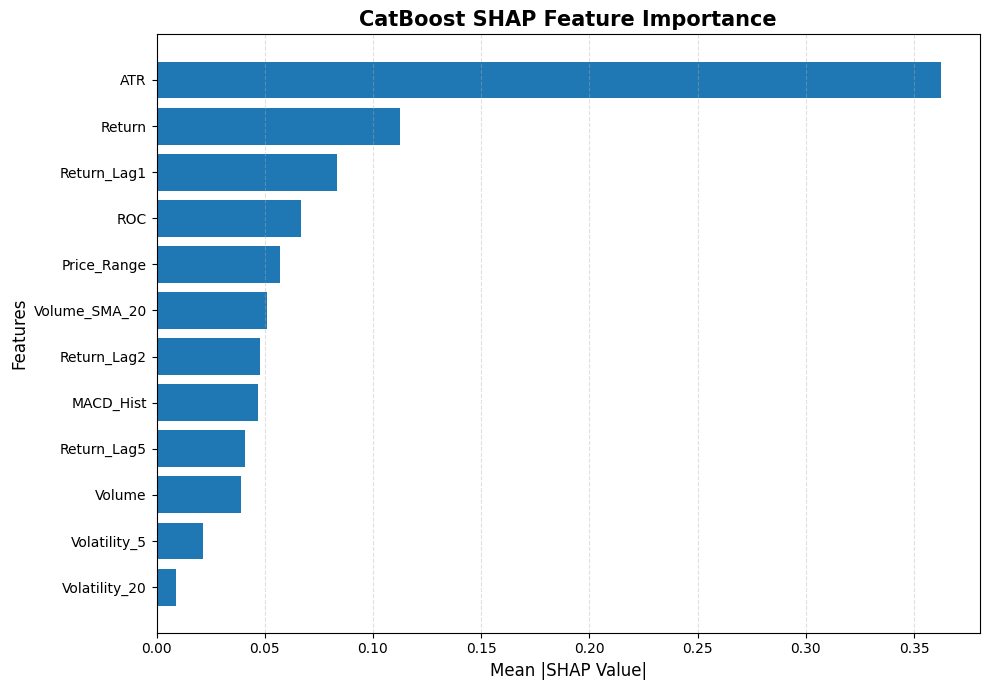

In [36]:
plt.figure(figsize=(10, 7))

plt.barh(
    shap_importance_df["Feature"][::-1],
    shap_importance_df["SHAP Importance"][::-1]
)

plt.xlabel("Mean |SHAP Value|", fontsize=12)
plt.ylabel("Features", fontsize=12)

plt.title(
    "CatBoost SHAP Feature Importance",
    fontsize=15,
    fontweight="bold"
)

plt.grid(
    axis="x",
    linestyle="--",
    alpha=0.4
)

plt.tight_layout()
plt.show()